In [1]:
import os
from pathlib import Path

try:
    from occultence import *
except:
    os.chdir("../..")
    from occultence import *
data_dir = "../../Data"
    
import occultence
occultence.version()

'0.5.13'

file_003


(0.99, 1.015)

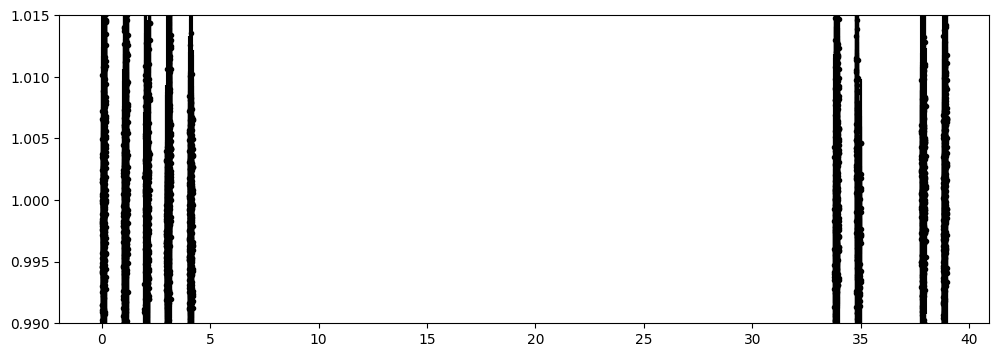

In [2]:
pre_bin = False

all_files = glob.glob(f"{data_dir}/file_*")
all_stars = pd.read_csv(f"{data_dir}/star_info.csv")

#select star/lightcurve to analyse
i = 19
file_to_use = all_files[i]
file_stem = Path(file_to_use).stem

#get light curve of selected star
data = pd.read_csv(file_to_use)

t = data["bjd"].values - data["bjd"].values[0]
f = data["diff_flux_use"].values
ferr = data["diff_error"].values

#get stellar parameters
star_info = all_stars[all_stars["TARGET"]==file_stem]

R_star = star_info["RAD"].values[0]
M_star = star_info["MASS"].values[0]
T_star = star_info["TEFF"].values[0]
name = star_info['TARGET'].values[0]
print(name)

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = name,
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':R_star*u.R_sun, 'M_star':M_star*u.M_sun,
                           'Teff':T_star * u.K})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



In [4]:
targ

<🌟 Lightcurve file_003 (2118t) 🌟>

In [5]:
# targ_with_transit = targ.clean().inject_transit(per=10*u.d, 
#                                         epoch=0.025 * u.d, 
#                                         inc=90 * u.degree, 
#                                         rp=2 * u.R_earth, 
#                                         ld=[0.3,0.3])

In [6]:
# targ.bin(dt=20*u.minute).time

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


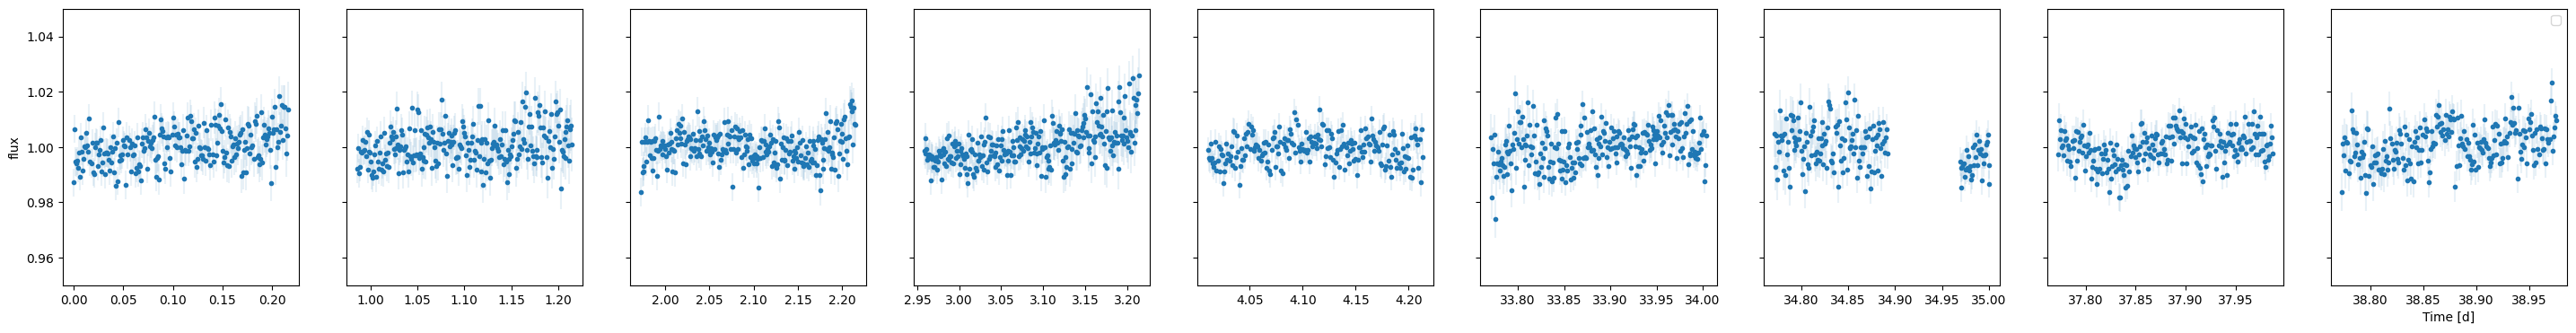

In [7]:
ax=targ.plot(ylims=[0.95,1.05])
# targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-",)

In [8]:
# a = targ.find_transits(transit_durations=[0.01,0.02,0.03,0.04],
#                             minimum_period=0.5, 
#                             maximum_period=30,
#                             oversample=10,
#                             obj="snr",
#                             minimum_n_transit=2,
#                            verbose=True, plot=True,
#                             nperiods=100000)

In [9]:
# per=2.55*u.d
# epoch=0.025 * u.d
# inc=90 * u.degree
# rp=1 * u.R_earth
# ld=[0.3,0.3]

# planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
#                                                           minimum_planet_radius=rp, 
#                                                           maximum_planet_radius=rp,
#                                                           minimum_period=per, 
#                                                           maximum_period=per,
#                                                         )
# planets

In [10]:
# lcs_with_transits, planets = targ.inject_lots_of_transits(nfake=10,
#                                                                   minimum_planet_radius=rp,
#                                                                   maximum_planet_radius=rp,
#                                                                   minimum_period=per,
#                                                                   maximum_period=10*u.d,
#                                                                   ld=ld,
#                                                           )

In [11]:
# lcs_with_transits

In [ ]:
x = full_injection_recovery(targ, 
                            # lcs_with_transits=[targ_with_transit],
                                # planets=planets,
                             nfake=5,
                             minimum_planet_radius=0.5 * u.R_earth, 
                             maximum_planet_radius=5 * u.R_earth,
                             minimum_period=1 * u.d, 
                             maximum_period=10 * u.d, 
                             ld=[0.65,0.28],  # use trappist-1 (Gillon+16)
                             clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True,
                                         'threshold_removal':False, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':False},
                             flare_kw = {'plot':False, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                         'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                         'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf}, 
                                         'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                             detrend_method = "gp", 
                             detrend_bin = 10 * u.minute,
                             detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                           'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': False, 'verbose':False,
                                           'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                           'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                 np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                            bls_kw = {"minimum_period":0.5, "maximum_period":30, 'minimum_n_transit':2, 'obj':'snr',
                                      'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 'plot':True, 
                                      'verbose': False, 'nperiods':100000, 'oversample':10,}, 
                            bls_bin=5 * u.minute,
                            recovery_kw = {'condition_on_epoch':1 * u.hour, 
                                           'min_n_transits': 1, 
                                           'meet_condition': 'any',
                                          'verbose':False},                           
                            verbose=False, plot=True, time_this_process=True,
                           plot_dir='../../Results/', save_plots=True, save_lcs=False,
                           # plot_kw={'ylims':[0.98,1.02]},
                           svname=f"../../Results/{name}_injected_planets.csv",
                           min_save=True)

1/5...
Time to clean LC: 0.472959041595459


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


No flares found.
Time to remove flares: 0.8119518756866455
Time to BLS before detrending: 7.764052867889404


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [38]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x

In [ ]:
# i=4
# ax=lcs[i].plot()
# lcs[i].plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")
# try:
#     print(lcs_bls[i][0].metadata['BLS_transits_found'])
# except:
#     print(False)
#     pass

In [39]:
# np.sqrt(planets_df['rec_depth']).values * 
from astropy.units import Quantity
planets_df['r_s'].apply(Quantity)

0      0.1 solRad
1      0.1 solRad
2      0.1 solRad
3      0.1 solRad
4      0.1 solRad
          ...    
495    0.1 solRad
496    0.1 solRad
497    0.1 solRad
498    0.1 solRad
499    0.1 solRad
Name: r_s, Length: 500, dtype: object

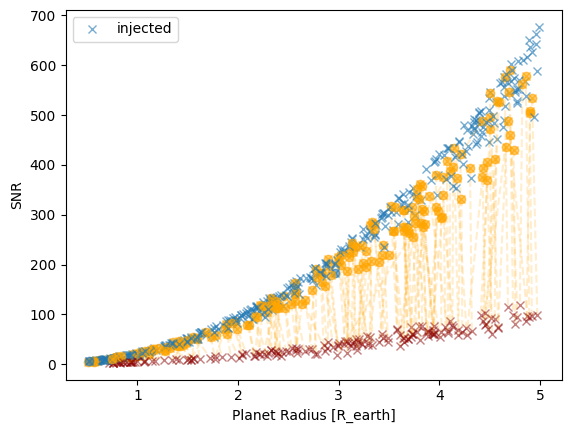

In [40]:
from astropy.units import Quantity

n_points_in_transit = planets_df['duration']/(7.5/(24*60))
lc_noise = 1e-3
rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s'].apply(Quantity)).values]

for i,(r_p, depth, rec, obs, r_p_rec, snr, n) in enumerate(zip(planets_df['r_p'], 
                                                          planets_df['depth'],  
                                                          planets_df['recovered'],
                                                          planets_df['observed'],
                                                          rec_r_p,  planets_df['snr'], 
                                                          n_points_in_transit)):
    if i == 0:
        labeli="injected"
        labelr="recovered"
        labelnr="not recovered"
        labelo="observed"
    else:
        labeli, labelr, labelnr, labelo = None, None, None,None
        
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
        
    if r_p_rec == 0.0:
        r_p_rec = r_p
        snr = depth * np.sqrt(n)/lc_noise
    plt.plot([r_p], [depth * np.sqrt(n)/lc_noise], 'x', color=color, alpha=0.6,label=labeli)
    plt.plot([r_p,r_p_rec], [depth * np.sqrt(n)/lc_noise, snr], '--', color=color, alpha=0.2)

    if obs == 1.0:
        plt.plot([r_p], [depth * np.sqrt(n)/lc_noise], 'o', color=color, alpha=0.6, label=labelo)
    
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5, label=labelr)
    
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")
plt.legend()

Fraction of injections observed: 0.368


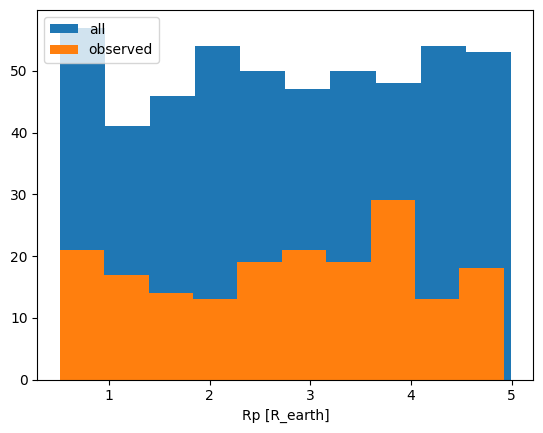

In [82]:
plt.hist(planets_df['r_p'], label='all')
plt.hist(planets_df['r_p'][planets_df['observed'] == 1.0], label='observed')
plt.xlabel("Rp [R_earth]")
plt.legend()

print(f"Fraction of injections observed: {len(planets_df['r_p'][planets_df['observed'] == 1.0])/len(planets_df['r_p'])}")

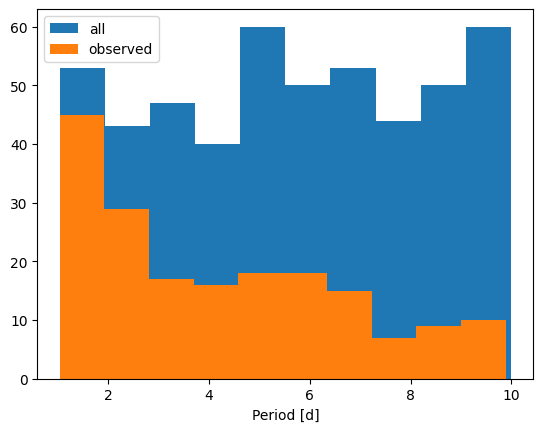

In [79]:
plt.hist(10**planets_df['logP'],label="all")
plt.hist(10**planets_df['logP'][planets_df['observed'] == 1.0], label="observed")
plt.xlabel("Period [d]")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


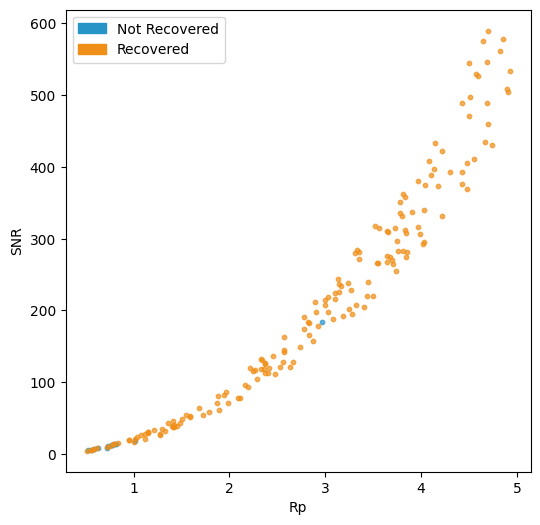

In [61]:
x = planets_df['r_p'][planets_df['observed'] == 1.0]
plot_transitparams(x=x, 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Rp", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=10,)
                   # svname=f"../../Results/{name}_injected_snr_Rp.png")

# plt.plot(sorted(x), (np.array(sorted(x))**2) * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0]) /lc_noise)

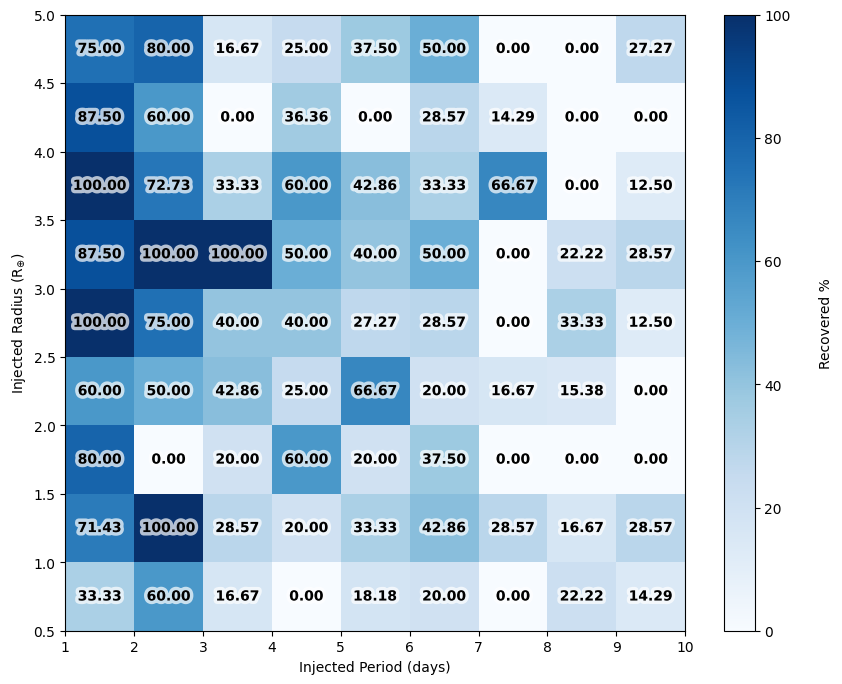

In [68]:
P_bins = np.linspace(1,10,10)
R_bins = np.linspace(0.5,5,10)

twod_plot(x=10**planets_df['logP'],
          y=planets_df['r_p'],
          z=planets_df['recovered'],
          x_bins=P_bins,
          y_bins=R_bins,
          zlabel="Recovered %",
          statistic="mean",
          addtext=True,)
          # svname=f"../../Results/{name}_recovered.png")

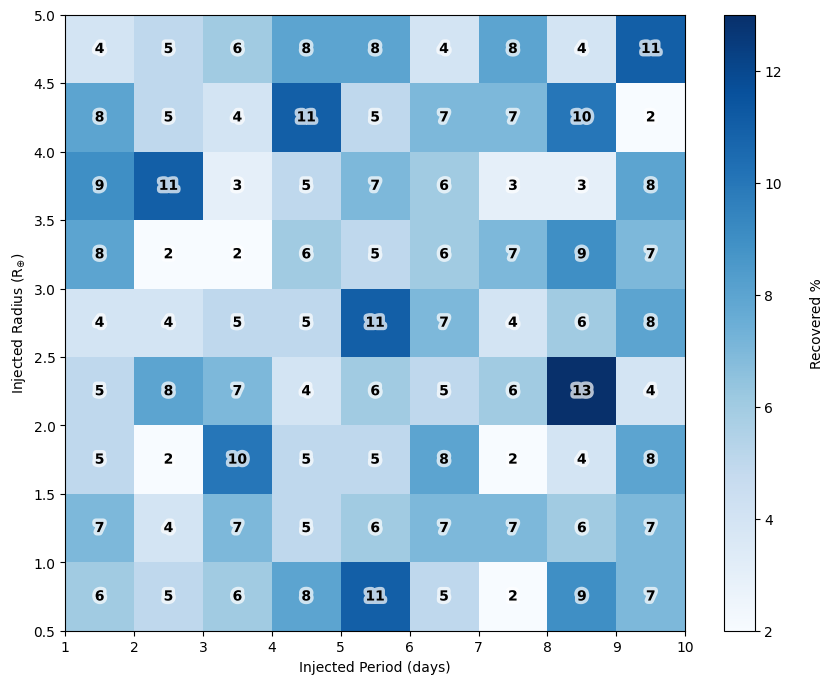

In [69]:
twod_plot(x=10**planets_df['logP'],
          y=planets_df['r_p'],
          z=planets_df['recovered'],
          x_bins=P_bins,
          y_bins=R_bins,
          zlabel="Recovered %",
          statistic="count",
          nsig="%0.0f",
          addtext=True,)